<a href="https://colab.research.google.com/github/kgakwaya/summative_Regression_Analysis/blob/main/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# CELL 1: ENVIRONMENT SETUP & AUTO-LOADING
# ==========================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

print("Libraries imported successfully!")

# Auto-detect uploaded CSV file
csv_files = glob.glob("*.csv")

if not csv_files:
    raise FileNotFoundError(
        "❌ No CSV file found in Colab! Please click the Folder icon on the left sidebar and upload your dataset CSV file."
    )

# Use the first CSV file found
target_file = csv_files[0]
print(f"Loading file: '{target_file}'...")

try:
    df_raw = pd.read_csv(target_file)
except Exception:
    df_raw = pd.read_csv(target_file, encoding='latin1')

print(f"Raw Dataset Shape: {df_raw.shape}")
df_raw.head()

Libraries imported successfully!
Loading file: 'Maternal Health Risk Data Set.csv'...
Raw Dataset Shape: (1014, 7)


,Age,SystolicBP,DiastolicBP,Blood sugar,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [2]:
# ==========================================
# CELL 2: DATA CLEANING & FEATURE SELECTION
# ==========================================
df = df_raw.copy()

# 1. Print original column names so you can inspect them
print("Original Columns found in CSV:", df.columns.tolist())

# 2. Clean column names (strip trailing/leading spaces and whitespace)
df.columns = df.columns.str.strip()

# 3. Map potential column name variations automatically
column_mapping = {
    'bs': 'BS',
    'blood sugar': 'BS',
    'Blood Sugar': 'BS',
    'systolicbp': 'SystolicBP',
    'diastolicbp': 'DiastolicBP',
    'bodytemp': 'BodyTemp',
    'heartrate': 'HeartRate',
    'risklevel': 'RiskLevel'
}

# Rename columns if they match lowercase or variation patterns
df = df.rename(columns={col: column_mapping[col.lower()] for col in df.columns if col.lower() in column_mapping})

print("Cleaned Column Names:", df.columns.tolist())

# 4. Target Variable and Features Selection
target_col = 'SystolicBP'

# List of expected features
expected_features = ['Age', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

# Filter only features that exist in your specific dataset
feature_cols = [col for col in expected_features if col in df.columns]

# Drop categorical 'RiskLevel' column if present
if 'RiskLevel' in df.columns:
    df = df.drop(columns=['RiskLevel'])

# Ensure all selected feature/target columns are numeric
for col in feature_cols + [target_col]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where target variable is missing
df_clean = df.dropna(subset=[target_col]).copy()

# Impute missing feature values with median
imputer = SimpleImputer(strategy='median')
df_clean[feature_cols] = imputer.fit_transform(df_clean[feature_cols])

print(f"\n✅ Data Cleaned Successfully! Shape: {df_clean.shape}")
print(f"Selected Features ({len(feature_cols)}): {feature_cols}")
print(f"Target Column: '{target_col}'")
df_clean.head()

Original Columns found in CSV: ['Age', 'SystolicBP', 'DiastolicBP', 'Blood sugar', 'BodyTemp', 'HeartRate', 'RiskLevel']
Cleaned Column Names: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']

✅ Data Cleaned Successfully! Shape: (1014, 6)
Selected Features (5): ['Age', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
Target Column: 'SystolicBP'


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,25.0,130,80.0,15.0,98.0,86.0
1,35.0,140,90.0,13.0,98.0,70.0
2,29.0,90,70.0,8.0,100.0,80.0
3,30.0,140,85.0,7.0,98.0,70.0
4,35.0,120,60.0,6.1,98.0,76.0


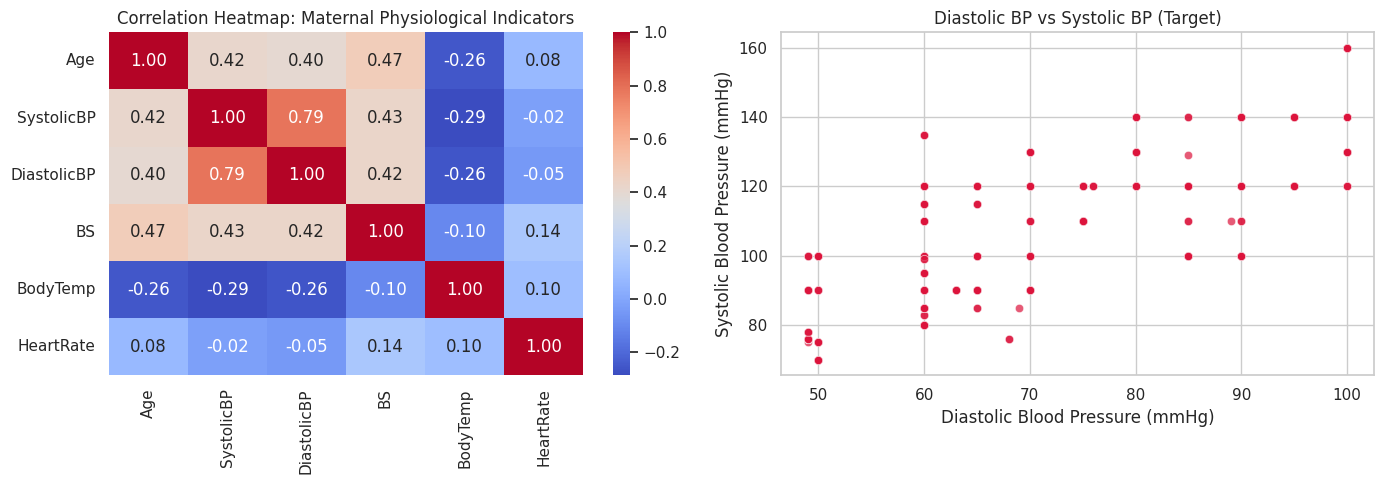

In [3]:
# ==========================================
# CELL 3: VISUALIZATIONS & INTERPRETATION
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visualization 1: Correlation Heatmap
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0])
axes[0].set_title("Correlation Heatmap: Maternal Physiological Indicators")

# Visualization 2: Diastolic BP vs Systolic BP Scatter Plot
sns.scatterplot(x=df_clean['DiastolicBP'], y=df_clean['SystolicBP'], color='crimson', alpha=0.7, ax=axes[1])
axes[1].set_title("Diastolic BP vs Systolic BP (Target)")
axes[1].set_xlabel("Diastolic Blood Pressure (mmHg)")
axes[1].set_ylabel("Systolic Blood Pressure (mmHg)")

plt.tight_layout()
plt.show()

In [4]:
# ==========================================
# CELL 4: DATA SPLITTING & STANDARDIZATION
# ==========================================
X = df_clean[feature_cols]
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler artifact for API deployment
joblib.dump(scaler, 'scaler.joblib')
print("Scaler successfully saved as 'scaler.joblib'!")

Scaler successfully saved as 'scaler.joblib'!


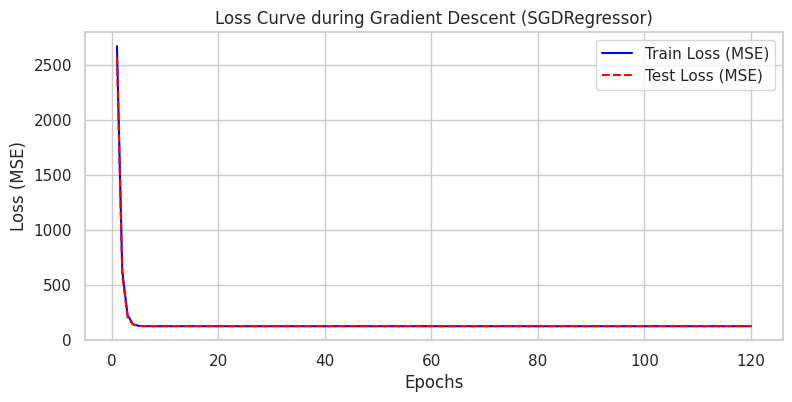

In [5]:
# ==========================================
# CELL 5: GRADIENT DESCENT & LOSS CURVE
# ==========================================
sgd = SGDRegressor(max_iter=1, warm_start=True, penalty=None, learning_rate='constant', eta0=0.001, random_state=42)

epochs = 120
train_losses = []
test_losses = []

for epoch in range(epochs):
    sgd.partial_fit(X_train_scaled, y_train)

    y_train_pred = sgd.predict(X_train_scaled)
    y_test_pred = sgd.predict(X_test_scaled)

    train_losses.append(mean_squared_error(y_train, y_train_pred))
    test_losses.append(mean_squared_error(y_test, y_test_pred))

# Plot Loss Curve
plt.figure(figsize=(9, 4))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss (MSE)', color='blue')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss (MSE)', color='red', linestyle='--')
plt.title('Loss Curve during Gradient Descent (SGDRegressor)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

=== Model Comparison Results ===
                                Model    MSE Loss       RMSE       MAE  \
3             Random Forest Regressor   46.497886   6.818936  4.361731   
2             Decision Tree Regressor   62.380136   7.898110  4.966793   
0  Stochastic Linear Regression (SGD)  122.102691  11.050009  8.878903   
1             Linear Regression (OLS)  122.261974  11.057214  8.893168   

   R2 Score  
3  0.856307  
2  0.807226  
0  0.622664  
1  0.622172  


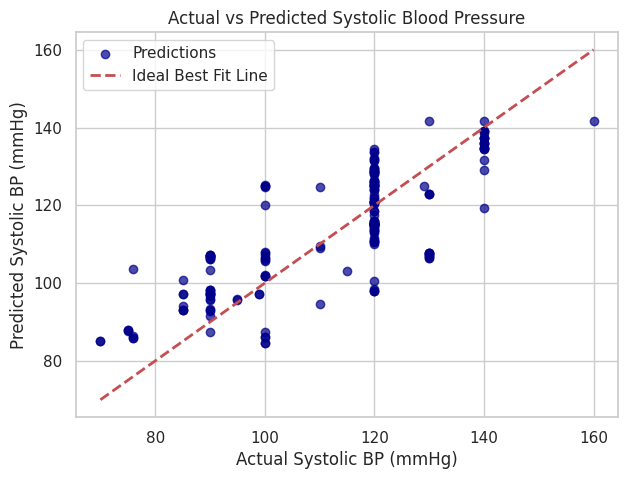

Best model 'Random Forest Regressor' saved as 'best_model.joblib' with MSE = 46.4979


In [6]:
# ==========================================
# CELL 6: ALGORITHM COMPARISON & MODEL EVALUATION
# ==========================================
models = {
    'Stochastic Linear Regression (SGD)': SGDRegressor(max_iter=1000, random_state=42),
    'Linear Regression (OLS)': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, preds)
    results.append({
        'Model': name,
        'MSE Loss': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_test, preds),
        'R2 Score': r2_score(y_test, preds),
        'Model_Obj': model
    })

results_df = pd.DataFrame(results).sort_values(by='MSE Loss')
print("=== Model Comparison Results ===")
print(results_df[['Model', 'MSE Loss', 'RMSE', 'MAE', 'R2 Score']])

# Plot Actual vs Best Fit Line for Linear Regression
lr_model = models['Linear Regression (OLS)']
lr_preds = lr_model.predict(X_test_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, lr_preds, color='darkblue', alpha=0.7, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Best Fit Line')
plt.title('Actual vs Predicted Systolic Blood Pressure')
plt.xlabel('Actual Systolic BP (mmHg)')
plt.ylabel('Predicted Systolic BP (mmHg)')
plt.legend()
plt.show()

# Save best performing model
best_model_info = results_df.iloc[0]
best_model = best_model_info['Model_Obj']
joblib.dump(best_model, 'best_model.joblib')
print(f"Best model '{best_model_info['Model']}' saved as 'best_model.joblib' with MSE = {best_model_info['MSE Loss']:.4f}")

In [7]:
# ==========================================
# CELL 7: SINGLE ROW PREDICTION & DOWNLOAD
# ==========================================
from google.colab import files

# Test prediction on 1 row from test set
sample_input = X_test.iloc[0:1]
sample_scaled = X_test_scaled[0:1]
actual_val = y_test.iloc[0]

predicted_val = best_model.predict(sample_scaled)[0]

print("=== Single Test Sample Prediction ===")
print("Input Features:", sample_input.to_dict(orient='records')[0])
print(f"Actual Systolic BP: {actual_val:.2f} mmHg")
print(f"Predicted Systolic BP: {predicted_val:.2f} mmHg")

# Download saved artifacts directly to your computer
files.download('best_model.joblib')
files.download('scaler.joblib')

=== Single Test Sample Prediction ===
Input Features: {'Age': 29.0, 'DiastolicBP': 70.0, 'BS': 7.7, 'BodyTemp': 98.0, 'HeartRate': 78.0}
Actual Systolic BP: 130.00 mmHg
Predicted Systolic BP: 120.34 mmHg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>